# Homework 9 - Dimensionality Reduction
In this homework, you will repeat the dimensionality reduction exploration from [class hands-on](../class) but with another dataset. And also provide your own observations of the data.

Feel free to choose your own dataset (like the one you are using for the final project), or to keep things simple, you can use the Cars dataset.

## Instructions

1. **Project Setup**:  
   - Set up your Python and Jupyter (or VSCode) environment.  
   - Clone or download the repository provided in class (refer to the class notes).

2. **Choose a Dataset**:  
   - You can use the Cars dataset or any other dataset of your choice.
   - Ensure your dataset has multiple numeric features and at least one categorical feature for coloring.

3. **Identify Features that numeric**:
   - Identify which features in your dataset are numeric. You can use the `select_dtypes` method in pandas to help with this.

4. **Choose and apply at least 2 dimensionality reduction techniques**:
   - You can use PCA, t-SNE, UMAP, or any other dimensionality reduction technique you learned about in class or from the literature.
   - Apply these techniques to your dataset and visualize the results.
   - Tell us if you find any interesting patterns or clusters visually in the data.

5. **Documentation**:  
   - Comment your code and add markdown explanations for each part of your analysis.

6. **Submission**:  
   - Ensure your notebook is complete and all cells are executed without errors.
   - Save your notebook and export as either PDF or HTML. If the visualizations using altair are not being shown in the html, submit a separated version with altair html. Refer to: https://altair-viz.github.io/getting_started/starting.html#publishing-your-visualization (you can use the `chart.save('chart_file.html')` method).
   - Submit to Canvas.

Ok let's import the packages

In [3]:
# For Jupyter notebooks, use 'widget' backend for interactivity
#%matplotlib widget
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
# make text editable in Illustrator
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# import altair
import altair as alt
alt.data_transformers.disable_max_rows()


DataTransformerRegistry.enable('default')

Now it is time to load a dataset. You can choose your own dataset or use the Cars dataset. If you want to use the Cars dataset, you can load it using the following code:


In [6]:

# Load ../Datasets/carfeatures.csv
df = pd.read_csv("/content/carfeatures.csv") # adjust the path as needed
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [8]:
# If you are using the car dataset, let's remove a few entries that
# are problematic for our analysis.
# The dataset seems to have some issues:
# Entry with highest Highway MPG
weirdEntry = df.loc[df['highway MPG'].idxmax()]
print(weirdEntry)
# probably a mistake
# remove it
df_cars = df[df['highway MPG'] < 100]
# also removing electric cars
df_cars = df_cars[df_cars['Engine Fuel Type'] != 'electric']
df_cars.head()

Make                                           Audi
Model                                            A6
Year                                           2017
Engine Fuel Type     premium unleaded (recommended)
Engine HP                                     252.0
Engine Cylinders                                4.0
Transmission Type                  AUTOMATED_MANUAL
Driven_Wheels                     front wheel drive
Number of Doors                                 4.0
Market Category                              Luxury
Vehicle Size                                Midsize
Vehicle Style                                 Sedan
highway MPG                                     354
city mpg                                         24
Popularity                                     3105
MSRP                                          51600
Name: 1119, dtype: object


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


### Dimension reduction choice 1
Choose one dimension reduction method and apply it to the dataset. Remember that some methods work better if you scale the data first. You can use the `StandardScaler` from `sklearn.preprocessing` to scale your data.

Create a plot using matplotlib or any other library of your choice to visualize the reduced dimensions. Try to color the points by a categorical variable in your dataset, if available. Alternativelly you can use a continuous variable to color the points.

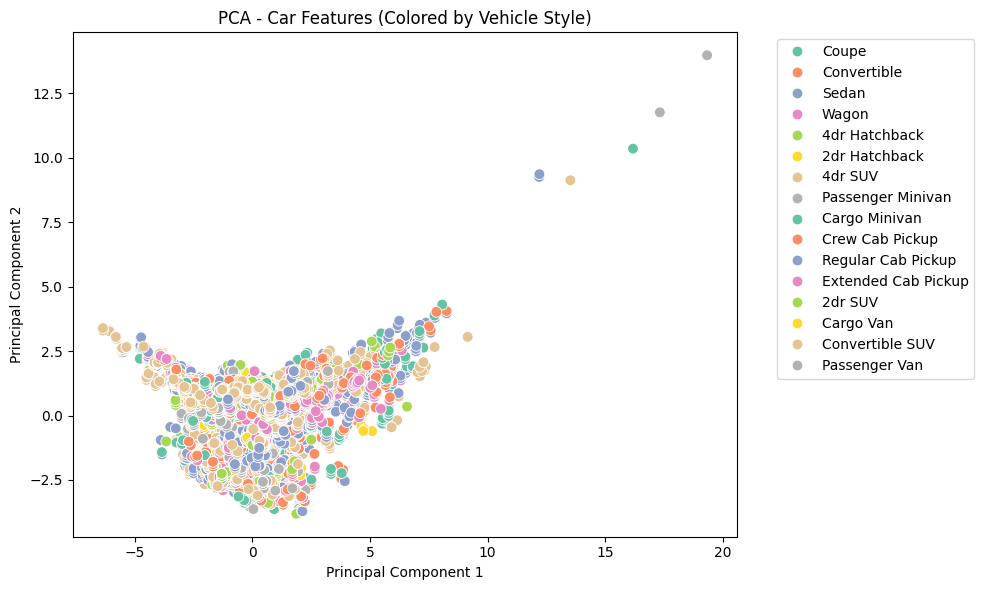

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Re-select numeric columns AFTER cleanup
numeric_cols = df_cars.select_dtypes(include=['number']).columns.tolist()

# Drop rows with NaNs in numeric columns
df_cars_clean = df_cars.dropna(subset=numeric_cols).copy()

# Scale the cleaned numeric data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cars_clean[numeric_cols])

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Prepare dataframe for plotting
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Category'] = df_cars_clean['Vehicle Style']

# Plot the PCA result
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Category', palette='Set2', s=60)
plt.title("PCA - Car Features (Colored by Vehicle Style)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


The PCA plot reduces the car dataset into two principal components while preserving as much variance as possible from the original numeric features.

The scatter plot shows some overlapping clusters, especially near the center, which indicates that many vehicle styles share similar numeric characteristics (e.g., weight, horsepower, acceleration).

A few outliers or distant points may correspond to unique vehicle types like Passenger Vans or Cargo Vans with extreme values.

Overall, PCA gives a general separation between some vehicle classes (e.g., hatchbacks vs. pickups) but doesn’t fully isolate categories — which is expected for a linear method.

### Dimension reduction choice 2
Repeat the previous step with a different dimension reduction method.

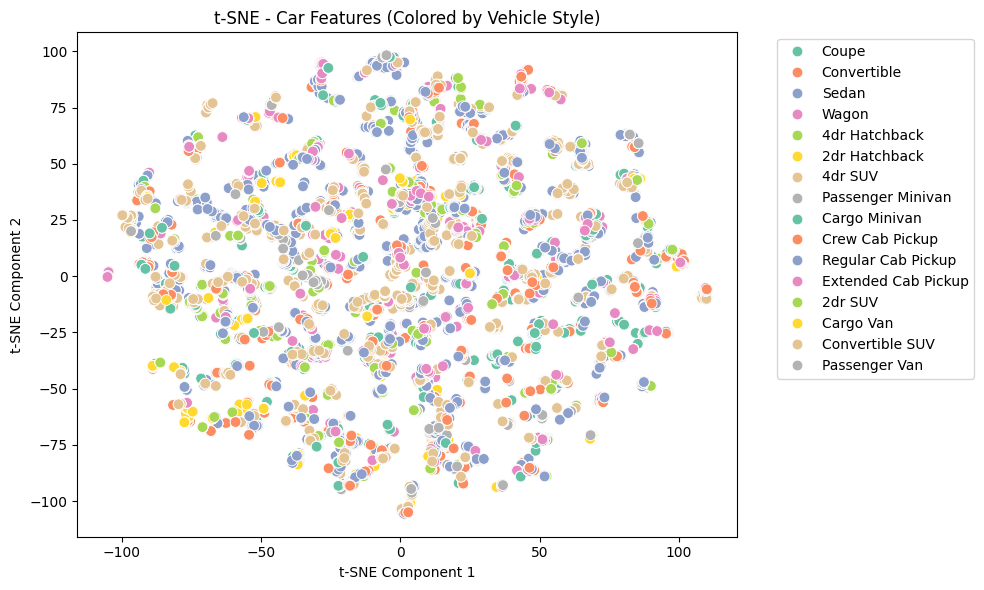

In [13]:
# YOUR CODE HERE
from sklearn.manifold import TSNE

# Apply t-SNE to the scaled numeric features
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Create DataFrame for plotting
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['Category'] = df_cars_clean['Vehicle Style']

# Plot t-SNE result
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='Category', palette='Set2', s=60)
plt.title("t-SNE - Car Features (Colored by Vehicle Style)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


The t-SNE plot shows a non-linear projection of the car dataset into two dimensions, revealing the local structure more effectively than PCA.

The data points are distributed in more distinct, localized clusters, which suggests that t-SNE is capturing subtle feature similarities between vehicle styles.

While there’s still overlap across categories like sedans, coupe, and hatchbacks, you can notice tight groupings for certain types like pickups and minivans.

Unlike PCA, which is linear and focuses on variance, t-SNE excels at local neighborhood preservation, making it more visually interpretable for understanding dense regions and small differences between vehicle styles.

This plot provides a complementary perspective to PCA and strengthens insights about category groupings within the dataset.

### Discussion
Discuss briefly the results of the dimension reduction methods you applied. What do you observe? Do the reduced dimensions capture any structure of the data? How do the two methods compare? Are there any interesting patterns or clusters in the data that can be observed visually?


 `YOUR DISCUSSION HERE`

I applied both PCA and t-SNE to reduce the high-dimensional car dataset to two dimensions and visualize any underlying patterns.

With PCA, the data mostly collapsed into a dense central cluster. There were some scattered outliers, but for the most part, it was difficult to distinguish any clear separation between vehicle styles. This suggests that while PCA captures overall variance, it didn’t isolate the classes well in this case.

t-SNE, which often excels at revealing local clusters, also produced a spread of points — but the categories were still highly intermixed. While a few small groupings appeared here and there, they weren’t strong or consistent enough to draw meaningful conclusions from.

Overall, both methods helped reduce the dimensionality of the data, but neither provided a very clear visual separation of vehicle types. This may be due to the nature of the features themselves — perhaps vehicle styles aren’t easily distinguishable using the available numeric data alone.

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


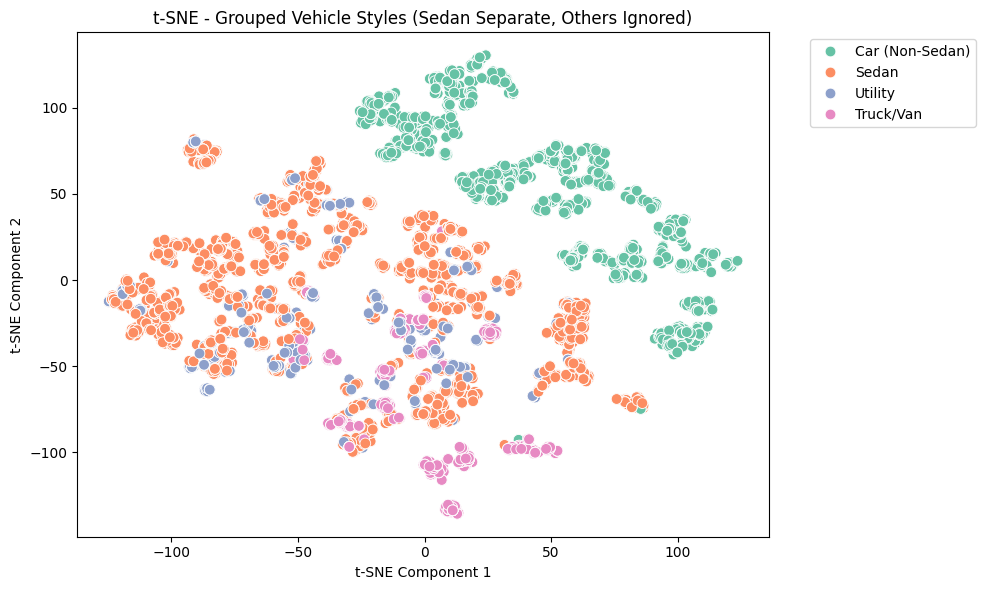

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Step 1: Refined grouping — keep Sedan separate
style_mapping = {
    'Sedan': 'Sedan',
    'Hatchback': 'Car (Non-Sedan)',
    'Coupe': 'Car (Non-Sedan)',
    'Convertible': 'Car (Non-Sedan)',
    'Wagon': 'Utility',
    'SUV': 'Utility',
    'Pickup': 'Truck/Van',
    'Passenger Van': 'Truck/Van',
    'Passenger Minivan': 'Truck/Van',
    'Cargo Van': 'Truck/Van'
}

# Step 2: Map vehicle styles to broader groups
df_cars_clean['Vehicle Group'] = df_cars_clean['Vehicle Style'].map(style_mapping)

# Step 3: Create a boolean mask for rows with known group
mask = df_cars_clean['Vehicle Group'].notna()

# Step 4: Apply mask to both DataFrame and scaled data
df_cars_filtered = df_cars_clean[mask].reset_index(drop=True)
X_scaled_filtered = X_scaled[mask.values]

# Step 5: Run t-SNE on filtered data
tsne = TSNE(n_components=2, perplexity=40, learning_rate=300, n_iter=2000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled_filtered)

# Step 6: Create DataFrame for plotting
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['Category'] = df_cars_filtered['Vehicle Group'].values

# Step 7: Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='Category', palette='Set2', s=60)
plt.title("t-SNE - Grouped Vehicle Styles (Sedan Separate, Others Ignored)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


After grouping vehicle styles into broader categories — keeping Sedan separate from other cars — the t-SNE visualization reveals much clearer structure compared to the original, more granular labeling.

The “Car (Non-Sedan)” category (including coupes, convertibles, and hatchbacks) forms a well-defined region in the upper right of the plot, distinctly separated from the rest. Sedans also form their own dense and relatively compact cluster in the middle-left, indicating that these vehicles share common numeric traits that differ from other car types.

Utility vehicles (SUVs, wagons) and Truck/Vans appear more spread out and somewhat mixed, but there are still small pockets of grouping — especially for trucks and cargo vehicles, which are likely more varied in size, engine type, or fuel efficiency.

Overall, this revised grouping strategy greatly improved interpretability. By simplifying categories, we allowed t-SNE to highlight meaningful patterns that were lost when using too many specific labels. This shows how thoughtful data preprocessing — like grouping similar classes — can significantly improve the clarity of dimensionality reduction outputs.